In [80]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

In [81]:
# CSV Master (path to be adjusted accordingly)
file_path = "../raw_data/xgboost_features_6s_final.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"done! {len(df)} lines")
    
    # check NaNs
    nans = df.isnull().sum().sum()
    print(f"missing values: {nans}")
    
    # columns
    print(f"cols: {df.columns.tolist()}")
    display(df.head())
else:
    print("check path")

done! 2978 lines
missing values: 0
cols: ['rms_mean', 'zcr_mean', 'centroid_mean', 'rolloff_mean', 'flatness_mean', 'flux_mean', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'patient_id', 'chunk_id', 'original_file', 'diagnosis']


,rms_mean,zcr_mean,centroid_mean,rolloff_mean,flatness_mean,flux_mean,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,patient_id,chunk_id,original_file,diagnosis
0,0.353044,0.000716,45.725212,44.022514,3.330234e-06,0.433962,62.103207,46.596294,35.124538,30.441692,...,24.450863,21.049578,19.102766,17.446293,14.485628,10.388805,223,0,223_1b1_Pr_sc_Meditron.wav,COPD
1,0.292240,0.000858,58.133667,60.941459,4.584547e-05,0.506965,69.266808,45.809357,29.296038,26.027634,...,23.123251,17.752768,16.974039,18.160587,16.474339,11.312906,223,1,223_1b1_Pr_sc_Meditron.wav,COPD
2,0.253082,0.000867,55.337952,51.920793,2.677925e-05,0.393950,57.963745,43.319889,33.574890,30.324558,...,24.443649,21.109665,19.139727,17.794617,14.825274,10.080499,223,2,223_1b1_Pr_sc_Meditron.wav,COPD
3,0.250386,0.000645,46.562109,33.339052,1.858933e-07,0.432056,64.634819,47.554161,35.159901,31.665985,...,25.265375,21.513996,19.771862,18.349688,14.735447,9.184393,223,3,223_1b1_Pr_sc_Meditron.wav,COPD
4,0.191456,0.000656,55.257088,42.525998,1.666906e-06,0.457763,78.567245,51.932735,32.147045,27.850620,...,27.659336,20.685802,18.205339,18.476448,16.082718,9.545835,223,4,223_1b1_Pr_sc_Meditron.wav,COPD


# load diagnosis - only if necessary. changed to markdown for the moment

print(df['diagnosis'].value_counts())

diag_path = "../raw_data/patient_diagnosis.csv" 

df_diag = pd.read_csv(diag_path)

df_diag.head()

## previous codes just for reference

df_diag = pd.read_csv(diag_path, names=['patient_id', 'diagnosis'])

df_diag

print("cols df_diag:", df_diag.columns.tolist())
print("1st lines df_diag:")
display(df_diag.head())

with open(diag_path, 'r') as f:
    for _ in range(5):
        print(f.readline())
#ok, missing header.

In [82]:
if 'diagnosis' in df.columns:
    print("diagnosis is in df")
    print(df['diagnosis'].value_counts())
    df_final = df.copy() # original
else:
    print("'diagnosis' was not found in the csv")

diagnosis is in df
diagnosis
COPD              2597
Pneumonia          111
Healthy            105
URTI                69
Bronchiectasis      48
Bronchiolitis       39
LRTI                 6
Asthma               3
Name: count, dtype: int64


In [83]:
# Drop Asthma and LRTI

classes_to_keep = ['COPD', 'Pneumonia', 'Healthy', 'URTI', 'Bronchiectasis', 'Bronchiolitis']

# Filter df
df_filtered = df[df['diagnosis'].isin(classes_to_keep)].copy()

print(f"original dataset: {len(df)} lines")
print(f"filtered one: {len(df_filtered)} lines")
print(f"\nnew dist:\n{df_filtered['diagnosis'].value_counts()}")

original dataset: 2978 lines
filtered one: 2969 lines

new dist:
diagnosis
COPD              2597
Pneumonia          111
Healthy            105
URTI                69
Bronchiectasis      48
Bronchiolitis       39
Name: count, dtype: int64


In [84]:
#crazy class imbalance. make XGboost ready:

In [85]:
#as diogo said: goldfish memory
print(df_filtered.columns.tolist())

['rms_mean', 'zcr_mean', 'centroid_mean', 'rolloff_mean', 'flatness_mean', 'flux_mean', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'patient_id', 'chunk_id', 'original_file', 'diagnosis']


## IT'S TIME FOR XGBOOST - just keeping this for later, because its not working :(

# but 1st: cross validation setup
# Using 5-fold or 3-fold? cv - maybe 3 is better for ashtma and the ones that don't have a lot of referebce?
gkf = GroupKFold(n_splits=3)

#error because we don't have sequential classes on the split. adding
num_classes = len(np.unique(y))

# modeml training loop

fold = 1
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # initialize XGBoost classifier
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob', # used for multiclass classification
        num_class=num_classes, # gemini suggested this due to the error of class numbers
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    
    # train the model
    model.fit(X_train, y_train)
    
    # evaluet current fold
    score = model.score(X_test, y_test)
    print(f"fold {fold} accuracy: {score:.4f}")
    
    # stop at first fold - initial validation
    if fold == 1:
        y_pred = model.predict(X_test)
        print("\n classification report - fold 1:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        
        # confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Fold 1')
        plt.show()
        
    fold += 1



# IT'S TIME FOR XGBOOST 2nd TRYYYY

#filter and cleaning


# transform words (COPD, Healthy...) in num (0, 1, 2...)
le = LabelEncoder()
df_filtered['target'] = le.fit_transform(df_filtered['diagnosis'])

# so we know who is who
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"class mapping: {mapping}")

# define X and y (target)
# remove columns that are not numbers for now?
cols_to_drop = ['original_file', 'patient_id', 'diagnosis', 'target', 'chunk_id']
X = df_filtered.drop(columns=[c for c in cols_to_drop if c in df_filtered.columns])
    
y = df_filtered['target']
groups = df_filtered['patient_id'] # split per id

print(f"features: {X.shape[1]} cols")


#data cleaning - rare classes

classes_to_keep = ['COPD', 'Pneumonia', 'Healthy', 'URTI', 'Bronchiectasis', 'Bronchiolitis']
df_filtered = df_final[df_final['diagnosis'].isin(classes_to_keep)].copy()

df_filtered = df_filtered.reset_index(drop=True)


print(f"dropped classes: {set(df_final['diagnosis'].unique()) - set(to_keep)}")

# reencode sequentially 

# that's a must 0, 1, 2, 3... according to gemini: leave no no gaps
le_final = LabelEncoder()
df_filtered['target'] = le_final.fit_transform(df_filtered['diagnosis'])

X = df_filtered.drop(columns=[c for c in cols_to_drop if c in df_filtered.columns])
y = df_filtered['target']
groups = df_filtered['patient_id']

# training loop - from previous code

gkf = GroupKFold(n_splits=3)
fold = 1

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    w_train = compute_sample_weight(class_weight='balanced', y=y_train) # adding to try to balance these imbalanced classes
    
    # XGBoost should be happy because y starts at 0 and is sequential :)
    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob',# used for multiclass classification
        #num_class=num_classes, # gemini suggested this due to the error of class numbers - not needed now
        random_state=42,
        eval_metric='mlogloss'
    )
    
    model.fit(X_train, y_train, sample_weight=w_train)

    y_pred = model.predict(X_test)
    score = model.score(X_test, y_test)
    print(f"\nfold {fold} acc: {score:.4f} ---")

    present_labels = np.unique(y_test)
    target_names = [le_final.classes_[i] for i in present_labels]

    print(classification_report(y_test, y_pred, labels=present_labels, target_names=target_names))
    

    fold += 1



In [87]:
# filter and clean
# avoid label gaps
classes_to_keep = ['COPD', 'Pneumonia', 'Healthy', 'URTI', 'Bronchiectasis', 'Bronchiolitis']
df_filtered = df_final[df_final['diagnosis'].isin(classes_to_keep)].copy()
df_filtered = df_filtered.reset_index(drop=True)

# encode - sequentially (0, 1, 2...) ONLY!!! on the filtered data
le_final = LabelEncoder()
df_filtered['target'] = le_final.fit_transform(df_filtered['diagnosis'])

mapping = dict(zip(le_final.classes_, le_final.transform(le_final.classes_)))
print(f"Class mapping: {mapping}")

# define X (features), y (target) and groups 
cols_to_drop = ['original_file', 'patient_id', 'diagnosis', 'target', 'chunk_id']
X = df_filtered.drop(columns=[c for c in cols_to_drop if c in df_filtered.columns])
y = df_filtered['target']
groups = df_filtered['patient_id']

print(f"Features: {X.shape[1]} columns | Samples: {len(X)}")

# training loop
gkf = GroupKFold(n_splits=3)
fold = 1

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    # split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # calculate weights - for imbalance
    w_train = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # XGBoost w the correct num of classes
    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob',
        num_class=len(le_final.classes_),
        random_state=42,
        eval_metric='mlogloss'
    )
    
    # train
    model.fit(X_train, y_train, sample_weight=w_train)

    # predict
    y_pred = model.predict(X_test)
    score = model.score(X_test, y_test)
    
    print(f"\n--- fold {fold} | acc: {score:.4f} ---")

    # dynamic target names for the classification report
    present_labels = np.unique(y_test)
    target_names = [le_final.classes_[i] for i in present_labels]

    print(classification_report(y_test, y_pred, labels=present_labels, target_names=target_names))
    
    fold += 1

Class mapping: {'Bronchiectasis': np.int64(0), 'Bronchiolitis': np.int64(1), 'COPD': np.int64(2), 'Healthy': np.int64(3), 'Pneumonia': np.int64(4), 'URTI': np.int64(5)}
Features: 18 columns | Samples: 2969

--- fold 1 | acc: 0.8507 ---
                precision    recall  f1-score   support

Bronchiectasis       0.33      0.33      0.33        12
 Bronchiolitis       0.25      0.07      0.11        15
          COPD       0.97      0.93      0.95       874
       Healthy       0.22      0.47      0.30        30
     Pneumonia       0.10      0.11      0.10        36
          URTI       0.25      0.29      0.27        24

      accuracy                           0.85       991
     macro avg       0.35      0.37      0.34       991
  weighted avg       0.88      0.85      0.86       991


--- fold 2 | acc: 0.8424 ---
                precision    recall  f1-score   support

Bronchiectasis       0.50      0.40      0.44        15
 Bronchiolitis       0.00      0.00      0.00         6
  

<Figure size 1000x800 with 0 Axes>

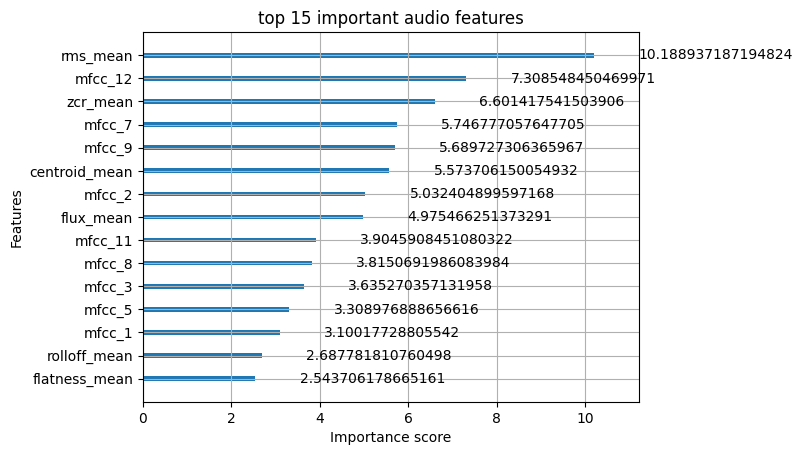

In [88]:
# feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('top 15 important audio features')
plt.show()
